In [1]:
# Install all required libraries
# Run this cell once, then restart kernel

import subprocess
import sys

libraries = [
    'yfinance',
    'pandas',
    'numpy',  
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'scipy',
    'statsmodels',
    'gymnasium',
    'stable-baselines3[extra]',
    'optuna',
    'torch',
    'torchvision',
    'tensorboard',
    'plotly',
    'ta',           # Technical Analysis library
    'quantstats',   # Portfolio analytics
    'pyarrow',      # Fast parquet read/write
    'tqdm',
    'joblib',
    'pyyaml'
]

for lib in libraries:
    print(f'Installing {lib}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', lib, '-q'])

print('\nAll libraries installed successfully.')
print('Please restart the kernel before proceeding.')

Installing yfinance...
Installing pandas...
Installing numpy...
Installing matplotlib...
Installing seaborn...
Installing scikit-learn...
Installing scipy...
Installing statsmodels...
Installing gymnasium...
Installing stable-baselines3[extra]...
Installing optuna...
Installing torch...
Installing torchvision...
Installing tensorboard...
Installing plotly...
Installing ta...
Installing quantstats...
Installing pyarrow...
Installing tqdm...
Installing joblib...
Installing pyyaml...

All libraries installed successfully.
Please restart the kernel before proceeding.


In [2]:
import os
import warnings
import logging
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ─── Project Paths ────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('.')  # Change to your project root if needed
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw'
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
DATA_FEAT    = PROJECT_ROOT / 'data' / 'features'
RESULTS      = PROJECT_ROOT / 'results' / 'plots'

for path in [DATA_RAW, DATA_PROC, DATA_FEAT, RESULTS]:
    path.mkdir(parents=True, exist_ok=True)

# ─── Global Configuration ─────────────────────────────────────────────────────
CONFIG = {
    # Date range
    'start_date'      : '2005-01-01',
    'end_date'        : '2025-01-01',

    # Commodities
    'tickers'         : {
        'CL=F' : 'WTI_Crude_Oil',
        'GC=F' : 'Gold',
        'NG=F' : 'Natural_Gas',
        'SI=F' : 'Silver',
        'HG=F' : 'Copper'
    },
    'primary'         : 'CL=F',

    # Data quality thresholds
    'max_gap_days'    : 5,       # Max consecutive missing days before flagging
    'outlier_z_score' : 5.0,     # Z-score threshold for outlier detection
    'min_volume'      : 0,       # Minimum acceptable volume (0 = allow zero)

    # Crisis periods for later analysis
    'crisis_periods'  : {
        '2008_GFC'           : ('2008-09-01', '2009-03-31'),
        '2014_Oil_Collapse'  : ('2014-06-01', '2016-01-31'),
        '2020_COVID'         : ('2020-02-01', '2020-12-31'),
        '2022_Ukraine_War'   : ('2022-02-01', '2022-12-31')
    },

    # Plot style
    'figsize'         : (16, 8),
    'style'           : 'seaborn-v0_8-darkgrid'
}

plt.style.use(CONFIG['style'])
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

print('Configuration loaded successfully.')
print(f'Date range: {CONFIG["start_date"]} to {CONFIG["end_date"]}')
print(f'Commodities: {list(CONFIG["tickers"].values())}')

Configuration loaded successfully.
Date range: 2005-01-01 to 2025-01-01
Commodities: ['WTI_Crude_Oil', 'Gold', 'Natural_Gas', 'Silver', 'Copper']


In [3]:
def download_commodity_data(
    ticker: str,
    name: str,
    start: str,
    end: str,
    save_path: Path
) -> pd.DataFrame:
    """
    Download commodity OHLCV data from Yahoo Finance.
    Saves raw data to disk and returns DataFrame.
    """
    logger.info(f'Downloading {name} ({ticker}) from {start} to {end}...')

    try:
        df = yf.download(
            ticker,
            start=start,
            end=end,
            progress=False,
            auto_adjust=True  # Adjusts for splits and dividends
        )

        if df.empty:
            logger.warning(f'No data returned for {ticker}')
            return None

        # Flatten MultiIndex columns if present
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # Standardize column names
        df.columns = [c.lower().replace(' ', '_') for c in df.columns]
        df.index.name = 'date'
        df.index = pd.to_datetime(df.index)

        # Add metadata columns
        df['ticker'] = ticker
        df['commodity'] = name

        # Save raw data
        filepath = save_path / f'{name}_raw.parquet'
        df.to_parquet(filepath)
        logger.info(f'Saved {len(df)} rows to {filepath}')

        return df

    except Exception as e:
        logger.error(f'Failed to download {ticker}: {e}')
        return None


# ─── Download All Commodities ──────────────────────────────────────────────────
raw_data = {}

for ticker, name in CONFIG['tickers'].items():
    df = download_commodity_data(
        ticker=ticker,
        name=name,
        start=CONFIG['start_date'],
        end=CONFIG['end_date'],
        save_path=DATA_RAW
    )
    if df is not None:
        raw_data[name] = df

print(f'\nSuccessfully downloaded {len(raw_data)} commodities:')
for name, df in raw_data.items():
    print(f'  {name}: {len(df)} trading days | '
          f'{df.index.min().date()} to {df.index.max().date()}')

INFO:__main__:Downloading WTI_Crude_Oil (CL=F) from 2005-01-01 to 2025-01-01...
INFO:__main__:Saved 5030 rows to data\raw\WTI_Crude_Oil_raw.parquet
INFO:__main__:Downloading Gold (GC=F) from 2005-01-01 to 2025-01-01...
INFO:__main__:Saved 5026 rows to data\raw\Gold_raw.parquet
INFO:__main__:Downloading Natural_Gas (NG=F) from 2005-01-01 to 2025-01-01...
INFO:__main__:Saved 5031 rows to data\raw\Natural_Gas_raw.parquet
INFO:__main__:Downloading Silver (SI=F) from 2005-01-01 to 2025-01-01...
INFO:__main__:Saved 5027 rows to data\raw\Silver_raw.parquet
INFO:__main__:Downloading Copper (HG=F) from 2005-01-01 to 2025-01-01...
INFO:__main__:Saved 5030 rows to data\raw\Copper_raw.parquet



Successfully downloaded 5 commodities:
  WTI_Crude_Oil: 5030 trading days | 2005-01-03 to 2024-12-31
  Gold: 5026 trading days | 2005-01-03 to 2024-12-31
  Natural_Gas: 5031 trading days | 2005-01-03 to 2024-12-31
  Silver: 5027 trading days | 2005-01-03 to 2024-12-31
  Copper: 5030 trading days | 2005-01-03 to 2024-12-31


In [4]:
def run_quality_checks(
    df: pd.DataFrame,
    name: str,
    config: dict
) -> dict:
    """
    Comprehensive data quality checks.
    Returns a report dictionary.
    """
    report = {'commodity': name, 'issues': []}

    # ── 1. Missing Values ──────────────────────────────────────────────────────
    missing = df[['open', 'high', 'low', 'close', 'volume']].isnull().sum()
    report['missing_values'] = missing.to_dict()
    if missing.any():
        report['issues'].append(f'Missing values found: {missing[missing > 0].to_dict()}')

    # ── 2. Consecutive Missing Days ────────────────────────────────────────────
    full_range = pd.date_range(
        start=df.index.min(),
        end=df.index.max(),
        freq='B'  # Business days
    )
    missing_days = full_range.difference(df.index)
    report['missing_trading_days'] = len(missing_days)

    # Find consecutive gaps
    if len(missing_days) > 0:
        gaps = []
        current_gap = [missing_days[0]]
        for i in range(1, len(missing_days)):
            if (missing_days[i] - missing_days[i-1]).days <= 3:
                current_gap.append(missing_days[i])
            else:
                if len(current_gap) >= config['max_gap_days']:
                    gaps.append((current_gap[0], current_gap[-1], len(current_gap)))
                current_gap = [missing_days[i]]
        report['large_gaps'] = gaps
        if gaps:
            report['issues'].append(f'{len(gaps)} gaps larger than {config["max_gap_days"]} days')

    # ── 3. Outlier Detection ───────────────────────────────────────────────────
    returns = df['close'].pct_change().dropna()
    z_scores = np.abs(stats.zscore(returns))
    outliers = returns[z_scores > config['outlier_z_score']]
    report['outliers'] = {
        'count'  : len(outliers),
        'dates'  : outliers.index.tolist(),
        'values' : outliers.values.tolist()
    }
    if len(outliers) > 0:
        report['issues'].append(
            f'{len(outliers)} outlier returns (|z| > {config["outlier_z_score"]})'
        )

    # ── 4. Price Validity ──────────────────────────────────────────────────────
    # Check for negative prices (except WTI which went negative in April 2020)
    negative_prices = df[df['close'] < 0]
    report['negative_prices'] = len(negative_prices)
    if len(negative_prices) > 0:
        report['issues'].append(
            f'{len(negative_prices)} negative close prices '
            f'(dates: {negative_prices.index.tolist()})'
        )

    # Check OHLC integrity: high >= low, close within [low, high]
    ohlc_violations = df[
        (df['high'] < df['low']) |
        (df['close'] > df['high']) |
        (df['close'] < df['low'])
    ]
    report['ohlc_violations'] = len(ohlc_violations)
    if len(ohlc_violations) > 0:
        report['issues'].append(f'{len(ohlc_violations)} OHLC integrity violations')

    # ── 5. Return Distribution Statistics ────────────────────────────────────
    report['return_stats'] = {
        'mean'      : float(returns.mean()),
        'std'       : float(returns.std()),
        'skewness'  : float(returns.skew()),
        'kurtosis'  : float(returns.kurtosis()),
        'min'       : float(returns.min()),
        'max'       : float(returns.max())
    }

    # ── 6. Stationarity Tests ─────────────────────────────────────────────────
    # ADF test on price levels (expect non-stationary)
    adf_result = adfuller(df['close'].dropna(), autolag='AIC')
    report['adf_price'] = {
        'statistic'  : float(adf_result[0]),
        'p_value'    : float(adf_result[1]),
        'stationary' : adf_result[1] < 0.05
    }

    # ADF test on returns (expect stationary)
    adf_returns = adfuller(returns.dropna(), autolag='AIC')
    report['adf_returns'] = {
        'statistic'  : float(adf_returns[0]),
        'p_value'    : float(adf_returns[1]),
        'stationary' : adf_returns[1] < 0.05
    }

    return report


# ─── Run Checks on All Commodities ────────────────────────────────────────────
quality_reports = {}

for name, df in raw_data.items():
    report = run_quality_checks(df, name, CONFIG)
    quality_reports[name] = report

    print(f'\n{"─"*60}')
    print(f'Quality Report: {name}')
    print(f'{"─"*60}')
    print(f'  Rows              : {len(df)}')
    print(f'  Missing values    : {report["missing_values"]}')
    print(f'  Missing trd days  : {report["missing_trading_days"]}')
    print(f'  Outlier returns   : {report["outliers"]["count"]}')
    print(f'  Negative prices   : {report["negative_prices"]}')
    print(f'  OHLC violations   : {report["ohlc_violations"]}')
    print(f'  ADF price (p-val) : {report["adf_price"]["p_value"]:.4f} '
          f'({"stationary" if report["adf_price"]["stationary"] else "non-stationary"})')
    print(f'  ADF rets  (p-val) : {report["adf_returns"]["p_value"]:.4f} '
          f'({"stationary" if report["adf_returns"]["stationary"] else "non-stationary"})')
    print(f'  Return skewness   : {report["return_stats"]["skewness"]:.4f}')
    print(f'  Return kurtosis   : {report["return_stats"]["kurtosis"]:.4f}')

    if report['issues']:
        print(f'  ⚠ Issues:')
        for issue in report['issues']:
            print(f'    - {issue}')
    else:
        print(f'  ✓ No issues found')


────────────────────────────────────────────────────────────
Quality Report: WTI_Crude_Oil
────────────────────────────────────────────────────────────
  Rows              : 5030
  Missing values    : {'open': 0, 'high': 0, 'low': 0, 'close': 0, 'volume': 0}
  Missing trd days  : 187
  Outlier returns   : 3
  Negative prices   : 1
  OHLC violations   : 0
  ADF price (p-val) : 0.0191 (stationary)
  ADF rets  (p-val) : 0.0000 (stationary)
  Return skewness   : -39.4227
  Return kurtosis   : 2168.4164
  ⚠ Issues:
    - 3 outlier returns (|z| > 5.0)
    - 1 negative close prices (dates: [Timestamp('2020-04-20 00:00:00')])

────────────────────────────────────────────────────────────
Quality Report: Gold
────────────────────────────────────────────────────────────
  Rows              : 5026
  Missing values    : {'open': 0, 'high': 0, 'low': 0, 'close': 0, 'volume': 0}
  Missing trd days  : 191
  Outlier returns   : 10
  Negative prices   : 0
  OHLC violations   : 292
  ADF price (p-val) :

In [5]:
def handle_missing_values(
    df: pd.DataFrame,
    name: str
) -> pd.DataFrame:
    """
    Handle missing values using forward fill for short gaps.
    Flags and removes rows with large gaps.
    """
    df = df.copy()
    original_len = len(df)

    # Reindex to full business day range
    full_range = pd.date_range(
        start=df.index.min(),
        end=df.index.max(),
        freq='B'
    )
    df = df.reindex(full_range)
    df.index.name = 'date'

    # Forward fill for up to 3 consecutive missing days
    # (covers weekends and minor data gaps)
    price_cols = ['open', 'high', 'low', 'close']
    df[price_cols] = df[price_cols].fillna(method='ffill', limit=3)

    # Volume: fill with 0 for non-trading days
    df['volume'] = df['volume'].fillna(0)

    # Drop remaining NaN rows (large gaps at start of series)
    df_clean = df.dropna(subset=['close'])

    filled = len(df) - original_len
    dropped = len(df) - len(df_clean)

    print(f'{name}: '
          f'Added {filled} business days, '
          f'Forward-filled short gaps, '
          f'Dropped {dropped} unfillable rows. '
          f'Final: {len(df_clean)} rows.')

    return df_clean


# ─── Apply to All Commodities ─────────────────────────────────────────────────
clean_data = {}

for name, df in raw_data.items():
    clean_data[name] = handle_missing_values(df, name)

print('\nMissing value handling complete.')

WTI_Crude_Oil: Added 187 business days, Forward-filled short gaps, Dropped 0 unfillable rows. Final: 5217 rows.
Gold: Added 191 business days, Forward-filled short gaps, Dropped 0 unfillable rows. Final: 5217 rows.
Natural_Gas: Added 186 business days, Forward-filled short gaps, Dropped 0 unfillable rows. Final: 5217 rows.
Silver: Added 190 business days, Forward-filled short gaps, Dropped 0 unfillable rows. Final: 5217 rows.
Copper: Added 187 business days, Forward-filled short gaps, Dropped 0 unfillable rows. Final: 5217 rows.

Missing value handling complete.


In [6]:
def handle_outliers(
    df: pd.DataFrame,
    name: str,
    z_threshold: float = 5.0
) -> pd.DataFrame:
    """
    Handle outlier returns.

    Strategy:
    - We DO NOT remove outliers from commodity data because
      extreme events (COVID crash, oil price war) are genuine
      market events that the agent must learn to handle.
    - We FLAG them and winsorize only extreme OHLC violations.
    - WTI negative prices in April 2020 are kept as-is.
    """
    df = df.copy()

    # Calculate returns
    returns = df['close'].pct_change()

    # Flag outliers without removing them
    z_scores = np.abs(stats.zscore(returns.dropna()))
    outlier_mask = pd.Series(False, index=df.index)
    outlier_mask[returns.dropna().index[z_scores > z_threshold]] = True
    df['is_outlier'] = outlier_mask

    # Fix OHLC violations only (data errors, not genuine events)
    # Ensure high >= max(open, close) and low <= min(open, close)
    df['high'] = df[['high', 'open', 'close']].max(axis=1)
    df['low']  = df[['low',  'open', 'close']].min(axis=1)

    n_outliers = outlier_mask.sum()
    n_flagged_dates = df.index[outlier_mask].tolist()

    print(f'{name}: {n_outliers} outlier returns flagged (not removed)')
    if n_outliers > 0 and n_outliers <= 10:
        for d in n_flagged_dates:
            ret = returns.loc[d] if d in returns.index else 'N/A'
            print(f'  {d.date()}: return = {ret:.4f}')

    return df


# ─── Apply Outlier Handling ────────────────────────────────────────────────────
flagged_data = {}

for name, df in clean_data.items():
    flagged_data[name] = handle_outliers(df, name, CONFIG['outlier_z_score'])

print('\nOutlier handling complete.')

WTI_Crude_Oil: 3 outlier returns flagged (not removed)
  2020-04-20: return = -3.0597
  2020-04-21: return = -1.2660
  2020-04-22: return = 0.3766
Gold: 11 outlier returns flagged (not removed)
Natural_Gas: 10 outlier returns flagged (not removed)
  2006-09-28: return = 0.2835
  2009-09-29: return = 0.3070
  2009-10-29: return = 0.1802
  2010-10-28: return = 0.1817
  2018-11-14: return = 0.1795
  2020-09-29: return = 0.2189
  2022-01-27: return = 0.4648
  2022-01-28: return = -0.2595
  2024-04-29: return = 0.2577
  2024-10-30: return = 0.2127
Silver: 13 outlier returns flagged (not removed)
Copper: 7 outlier returns flagged (not removed)
  2006-05-23: return = 0.1196
  2008-10-10: return = -0.1104
  2008-10-29: return = 0.1249
  2008-10-30: return = -0.0883
  2008-12-08: return = 0.0908
  2009-01-06: return = 0.0860
  2009-02-06: return = 0.0860

Outlier handling complete.


In [7]:
def compute_roll_metrics(
    df: pd.DataFrame,
    name: str,
    roll_window: int = 21  # ~1 trading month
) -> pd.DataFrame:
    """
    Compute roll-related metrics for futures data.

    Since Yahoo Finance provides continuous front-month futures
    (already Panama-method adjusted), we compute:
    1. Rolling annualized roll yield proxy
    2. Contango/backwardation indicator
    3. Roll cost estimate based on price momentum

    Note: True roll yield requires full futures curve data.
    This is a proxy using the front-month continuous series.
    """
    df = df.copy()

    # ── Daily log returns ──────────────────────────────────────────────────────
    df['log_return']      = np.log(df['close'] / df['close'].shift(1))
    df['simple_return']   = df['close'].pct_change()

    # ── Rolling volatility (21-day) ────────────────────────────────────────────
    df['volatility_21d']  = df['log_return'].rolling(roll_window).std() * np.sqrt(252)

    # ── Rolling mean return ────────────────────────────────────────────────────
    df['mean_return_21d'] = df['log_return'].rolling(roll_window).mean() * 252

    # ── Momentum signals (used as contango/backwardation proxy) ───────────────
    # Positive momentum → backwardation tendency (spot > future)
    # Negative momentum → contango tendency (future > spot)
    df['momentum_1m']     = df['close'].pct_change(21)
    df['momentum_3m']     = df['close'].pct_change(63)
    df['momentum_6m']     = df['close'].pct_change(126)
    df['momentum_12m']    = df['close'].pct_change(252)

    # ── Contango indicator (proxy): negative 1m momentum suggests contango ────
    df['curve_signal']    = np.sign(df['momentum_1m'])

    # ── Roll cost proxy: based on near-expiry price pressure ──────────────────
    # Estimated as the difference between 1-month and 3-month momentum
    df['roll_cost_proxy'] = df['momentum_1m'] - df['momentum_3m'] / 3

    # ── Annualized Sharpe of rolling window ───────────────────────────────────
    df['rolling_sharpe']  = (
        df['log_return'].rolling(roll_window).mean() /
        df['log_return'].rolling(roll_window).std()
    ) * np.sqrt(252)

    print(f'{name}: Roll metrics computed. '
          f'Columns added: log_return, simple_return, volatility_21d, '
          f'momentum_1m/3m/6m/12m, curve_signal, roll_cost_proxy, rolling_sharpe')

    return df


# ─── Apply Roll Metrics ────────────────────────────────────────────────────────
processed_data = {}

for name, df in flagged_data.items():
    processed_data[name] = compute_roll_metrics(df, name)

print('\nRoll metrics computed for all commodities.')

WTI_Crude_Oil: Roll metrics computed. Columns added: log_return, simple_return, volatility_21d, momentum_1m/3m/6m/12m, curve_signal, roll_cost_proxy, rolling_sharpe
Gold: Roll metrics computed. Columns added: log_return, simple_return, volatility_21d, momentum_1m/3m/6m/12m, curve_signal, roll_cost_proxy, rolling_sharpe
Natural_Gas: Roll metrics computed. Columns added: log_return, simple_return, volatility_21d, momentum_1m/3m/6m/12m, curve_signal, roll_cost_proxy, rolling_sharpe
Silver: Roll metrics computed. Columns added: log_return, simple_return, volatility_21d, momentum_1m/3m/6m/12m, curve_signal, roll_cost_proxy, rolling_sharpe
Copper: Roll metrics computed. Columns added: log_return, simple_return, volatility_21d, momentum_1m/3m/6m/12m, curve_signal, roll_cost_proxy, rolling_sharpe

Roll metrics computed for all commodities.


In [8]:
def tag_crisis_periods(
    df: pd.DataFrame,
    crisis_periods: dict
) -> pd.DataFrame:
    """
    Tag each row with its crisis period if applicable.
    Used for crisis-period stress testing in Section 3.8.
    """
    df = df.copy()
    df['crisis_period'] = 'normal'

    for crisis_name, (start, end) in crisis_periods.items():
        mask = (df.index >= start) & (df.index <= end)
        df.loc[mask, 'crisis_period'] = crisis_name
        count = mask.sum()
        if count > 0:
            print(f'  Tagged {count} days as {crisis_name}')

    return df


# ─── Tag Crisis Periods ────────────────────────────────────────────────────────
print('Tagging crisis periods...')
for name in processed_data:
    print(f'\n{name}:')
    processed_data[name] = tag_crisis_periods(
        processed_data[name],
        CONFIG['crisis_periods']
    )

# Summary
print('\nCrisis period distribution (WTI):')
wti = processed_data['WTI_Crude_Oil']
print(wti['crisis_period'].value_counts())

Tagging crisis periods...

WTI_Crude_Oil:
  Tagged 152 days as 2008_GFC
  Tagged 435 days as 2014_Oil_Collapse
  Tagged 239 days as 2020_COVID
  Tagged 239 days as 2022_Ukraine_War

Gold:
  Tagged 152 days as 2008_GFC
  Tagged 435 days as 2014_Oil_Collapse
  Tagged 239 days as 2020_COVID
  Tagged 239 days as 2022_Ukraine_War

Natural_Gas:
  Tagged 152 days as 2008_GFC
  Tagged 435 days as 2014_Oil_Collapse
  Tagged 239 days as 2020_COVID
  Tagged 239 days as 2022_Ukraine_War

Silver:
  Tagged 152 days as 2008_GFC
  Tagged 435 days as 2014_Oil_Collapse
  Tagged 239 days as 2020_COVID
  Tagged 239 days as 2022_Ukraine_War

Copper:
  Tagged 152 days as 2008_GFC
  Tagged 435 days as 2014_Oil_Collapse
  Tagged 239 days as 2020_COVID
  Tagged 239 days as 2022_Ukraine_War

Crisis period distribution (WTI):
crisis_period
normal               4152
2014_Oil_Collapse     435
2020_COVID            239
2022_Ukraine_War      239
2008_GFC              152
Name: count, dtype: int64


In [9]:
def define_walkforward_splits(
    df: pd.DataFrame,
    initial_train_years : int  = 3,
    test_window_months  : int  = 6,
    step_months         : int  = 6
) -> list:
    """
    Define expanding window walk-forward splits.

    Returns list of (train_start, train_end, test_start, test_end) tuples.

    Example with initial_train_years=3, test_window_months=6, step_months=6:
    Split 1: Train 2005-2008, Test 2008 H1
    Split 2: Train 2005-2008 H1, Test 2008 H2
    ... and so on expanding the training window each time
    """
    splits = []

    start_date    = df.index.min()
    end_date      = df.index.max()

    # Initial training end
    train_end = start_date + pd.DateOffset(years=initial_train_years)

    while True:
        test_start = train_end
        test_end   = test_start + pd.DateOffset(months=test_window_months)

        if test_end > end_date:
            break

        splits.append({
            'train_start' : start_date,
            'train_end'   : train_end,
            'test_start'  : test_start,
            'test_end'    : test_end,
            'train_days'  : len(df[df.index < train_end]),
            'test_days'   : len(df[(df.index >= test_start) & (df.index < test_end)])
        })

        train_end = train_end + pd.DateOffset(months=step_months)

    return splits


# ─── Define Splits on WTI (primary commodity) ─────────────────────────────────
wti_df = processed_data['WTI_Crude_Oil']
splits = define_walkforward_splits(
    wti_df,
    initial_train_years=3,
    test_window_months=6,
    step_months=6
)

print(f'Walk-forward splits defined: {len(splits)} total periods')
print(f'\nFirst 3 splits:')
for i, s in enumerate(splits[:3]):
    print(f'  Split {i+1}: '
          f'Train {s["train_start"].date()} → {s["train_end"].date()} '
          f'({s["train_days"]} days) | '
          f'Test {s["test_start"].date()} → {s["test_end"].date()} '
          f'({s["test_days"]} days)')

print(f'\nLast split:')
s = splits[-1]
print(f'  Split {len(splits)}: '
      f'Train {s["train_start"].date()} → {s["train_end"].date()} '
      f'({s["train_days"]} days) | '
      f'Test {s["test_start"].date()} → {s["test_end"].date()} '
      f'({s["test_days"]} days)')

# Save splits definition
import json
splits_serializable = [
    {k: str(v) if isinstance(v, pd.Timestamp) else v for k, v in s.items()}
    for s in splits
]
with open(DATA_PROC / 'walkforward_splits.json', 'w') as f:
    json.dump(splits_serializable, f, indent=2)
print('\nSplits saved to data/processed/walkforward_splits.json')

Walk-forward splits defined: 33 total periods

First 3 splits:
  Split 1: Train 2005-01-03 → 2008-01-03 (783 days) | Test 2008-01-03 → 2008-07-03 (130 days)
  Split 2: Train 2005-01-03 → 2008-07-03 (913 days) | Test 2008-07-03 → 2009-01-03 (132 days)
  Split 3: Train 2005-01-03 → 2009-01-03 (1045 days) | Test 2009-01-03 → 2009-07-03 (129 days)

Last split:
  Split 33: Train 2005-01-03 → 2024-01-03 (4957 days) | Test 2024-01-03 → 2024-07-03 (130 days)

Splits saved to data/processed/walkforward_splits.json


Generating visualizations...


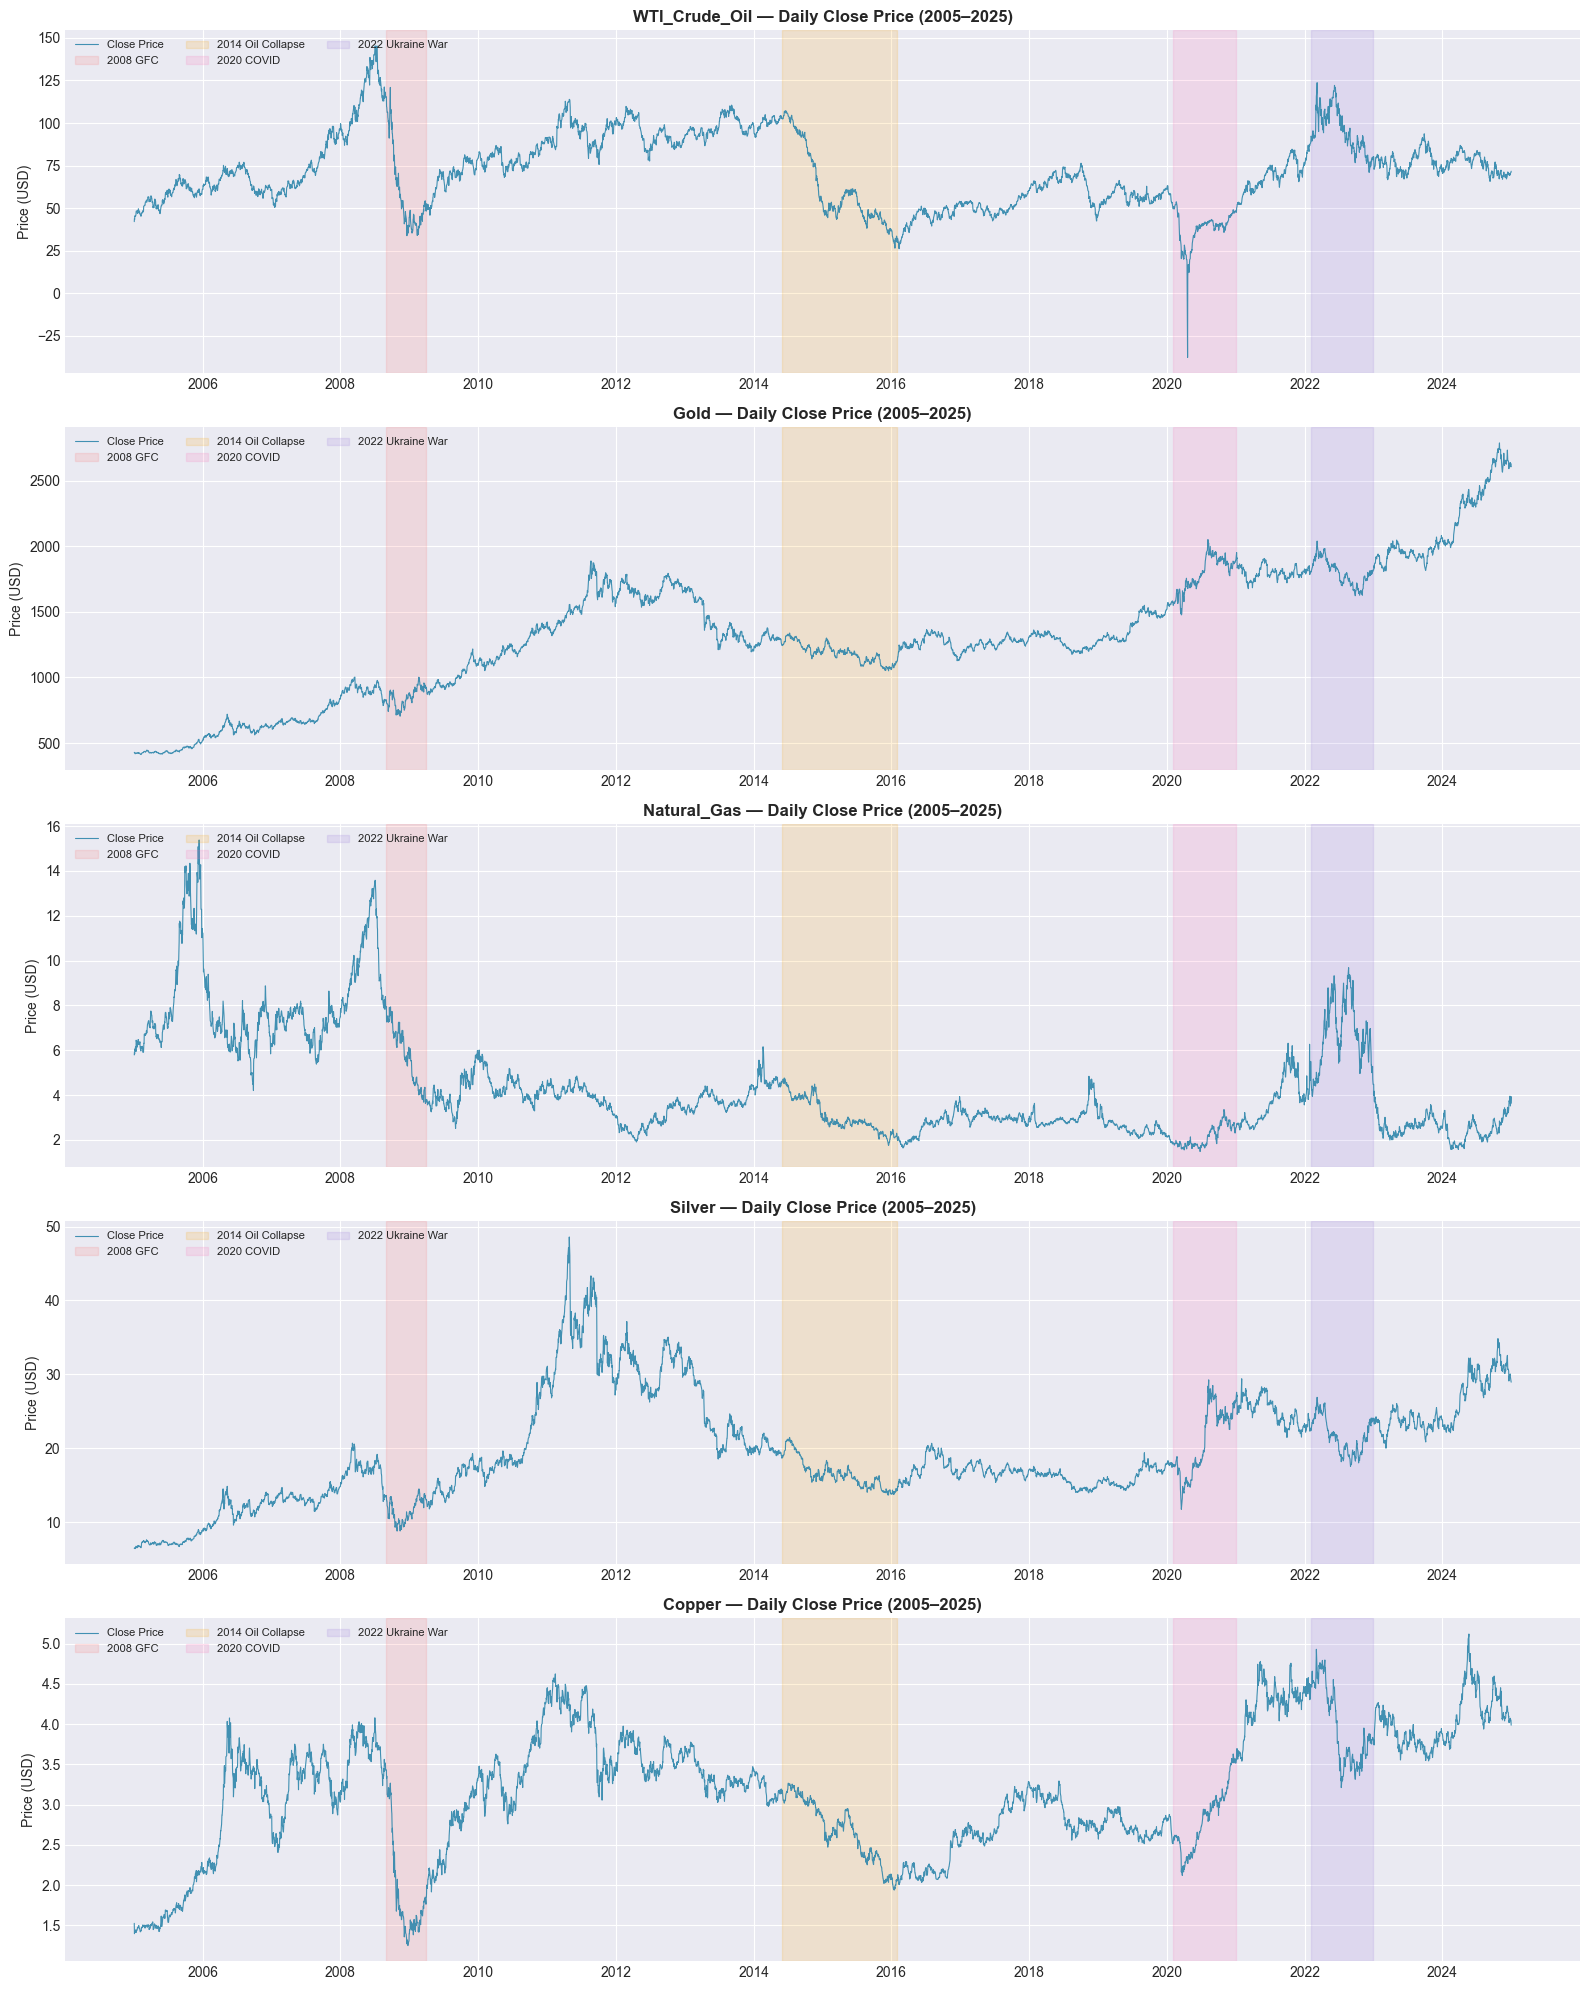

Saved to results\plots\price_history_all_commodities.png


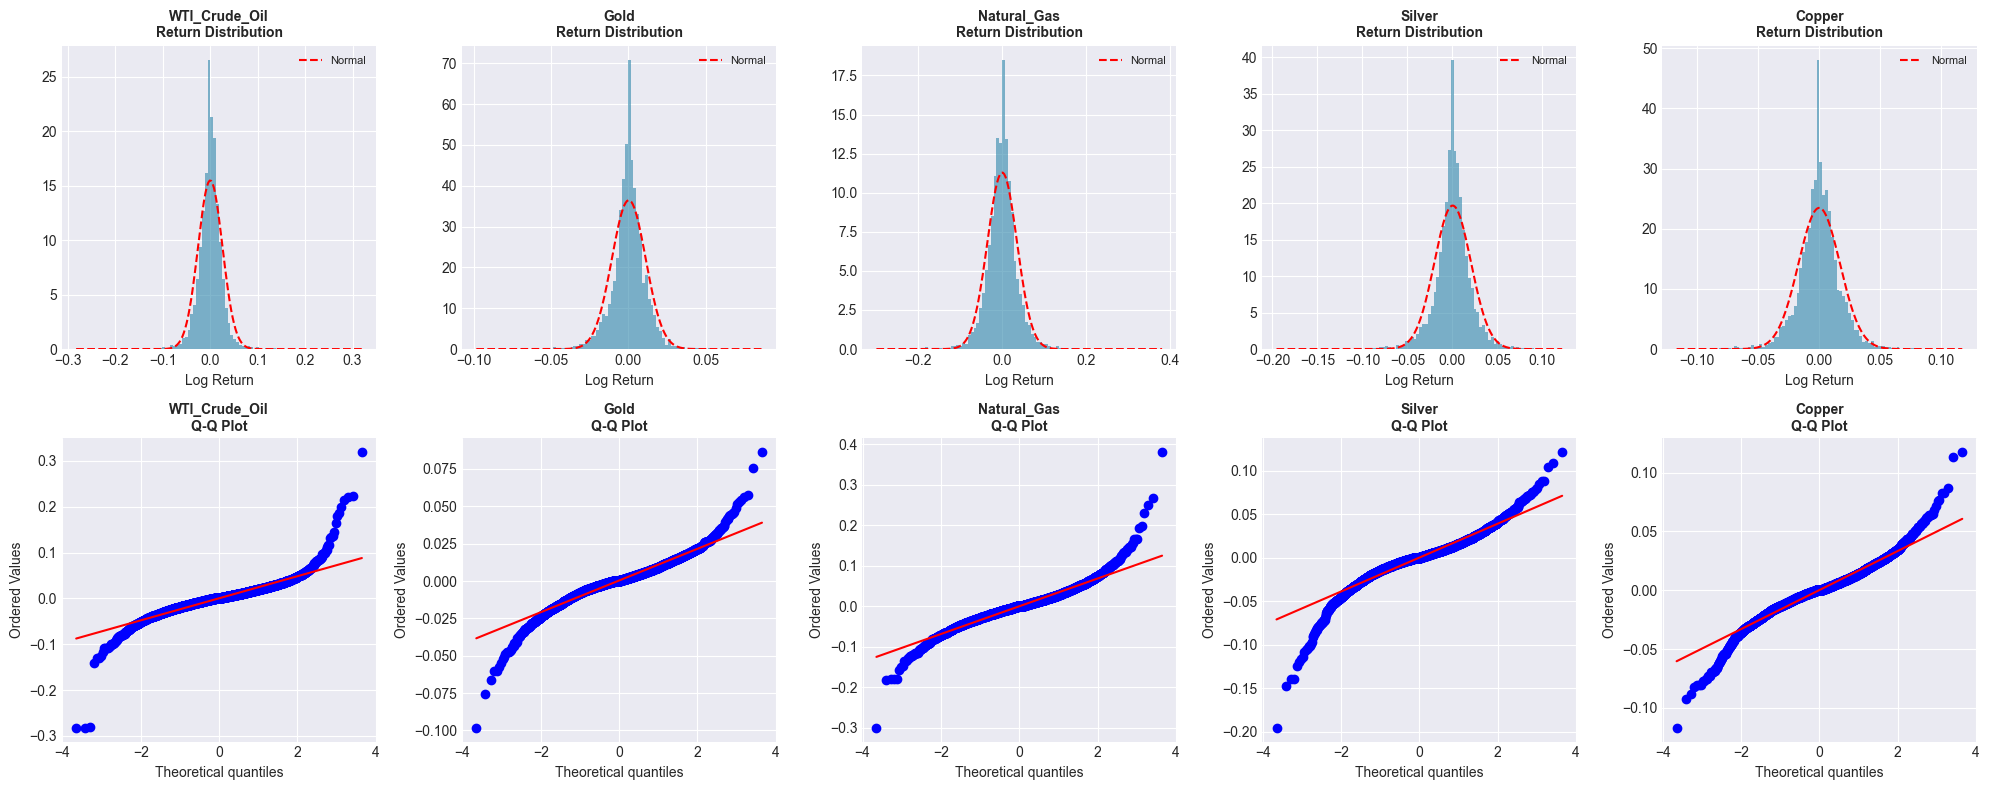

Saved to results\plots\return_distributions.png


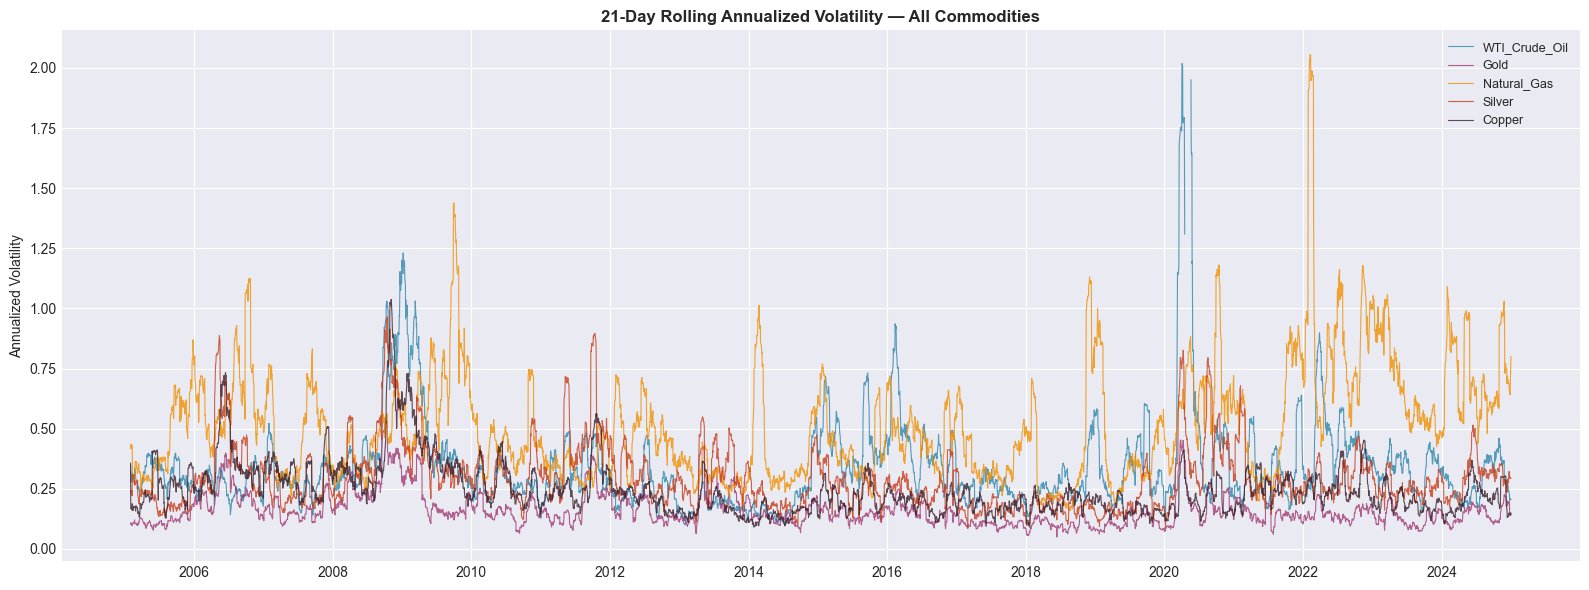

Saved to results\plots\volatility_regimes.png


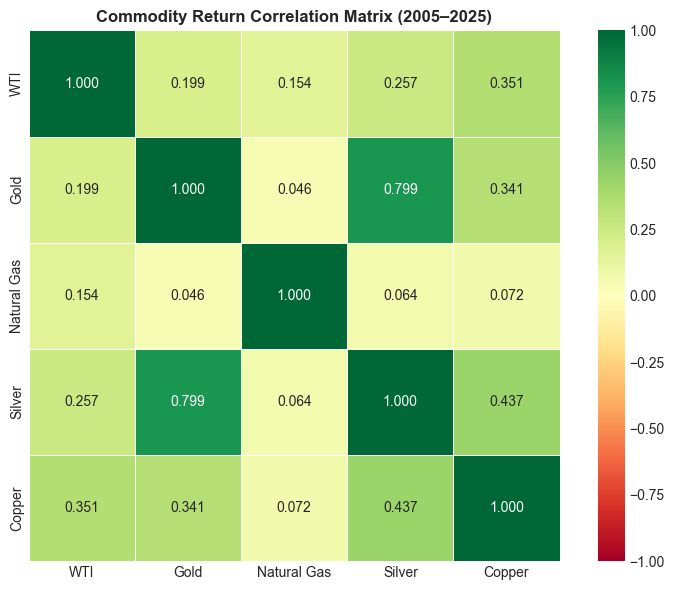

Saved to results\plots\correlation_matrix.png


In [10]:
def plot_price_history(
    data      : dict,
    config    : dict,
    save_path : Path
) -> None:
    """
    Plot normalized price history for all commodities
    with crisis periods highlighted.
    """
    fig, axes = plt.subplots(len(data), 1,
                              figsize=(16, 4 * len(data)),
                              sharex=False)

    crisis_colors = {
        '2008_GFC'          : '#FF6B6B',
        '2014_Oil_Collapse' : '#FFA500',
        '2020_COVID'        : '#FF69B4',
        '2022_Ukraine_War'  : '#9370DB'
    }

    for ax, (name, df) in zip(axes, data.items()):
        # Plot price
        ax.plot(df.index, df['close'],
                linewidth=0.8, color='#2E86AB', alpha=0.9,
                label='Close Price')

        # Highlight crisis periods
        for crisis_name, (start, end) in config['crisis_periods'].items():
            ax.axvspan(
                pd.Timestamp(start),
                pd.Timestamp(end),
                alpha=0.15,
                color=crisis_colors[crisis_name],
                label=crisis_name.replace('_', ' ')
            )

        ax.set_title(f'{name} — Daily Close Price (2005–2025)',
                     fontsize=12, fontweight='bold')
        ax.set_ylabel('Price (USD)', fontsize=10)
        ax.legend(loc='upper left', fontsize=8, ncol=3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(2))

    plt.tight_layout()
    filepath = save_path / 'price_history_all_commodities.png'
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {filepath}')


def plot_return_distributions(
    data      : dict,
    save_path : Path
) -> None:
    """
    Plot return distribution for each commodity.
    Shows fat tails and non-normality.
    """
    fig, axes = plt.subplots(2, len(data),
                              figsize=(4 * len(data), 8))

    for i, (name, df) in enumerate(data.items()):
        returns = df['log_return'].dropna()

        # Histogram + KDE
        axes[0, i].hist(returns, bins=100, density=True,
                         alpha=0.6, color='#2E86AB', edgecolor='none')

        # Overlay normal distribution
        x = np.linspace(returns.min(), returns.max(), 200)
        normal_pdf = stats.norm.pdf(x, returns.mean(), returns.std())
        axes[0, i].plot(x, normal_pdf, 'r--', linewidth=1.5,
                         label='Normal')
        axes[0, i].set_title(f'{name}\nReturn Distribution',
                               fontsize=10, fontweight='bold')
        axes[0, i].legend(fontsize=8)
        axes[0, i].set_xlabel('Log Return')

        # QQ Plot
        stats.probplot(returns, dist='norm', plot=axes[1, i])
        axes[1, i].set_title(f'{name}\nQ-Q Plot', fontsize=10, fontweight='bold')

    plt.tight_layout()
    filepath = save_path / 'return_distributions.png'
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {filepath}')


def plot_volatility_regimes(
    data      : dict,
    save_path : Path
) -> None:
    """
    Plot rolling volatility to visualize regime changes.
    """
    fig, ax = plt.subplots(figsize=(16, 6))

    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']

    for (name, df), color in zip(data.items(), colors):
        ax.plot(df.index, df['volatility_21d'],
                linewidth=0.8, color=color, alpha=0.8, label=name)

    ax.set_title('21-Day Rolling Annualized Volatility — All Commodities',
                  fontsize=12, fontweight='bold')
    ax.set_ylabel('Annualized Volatility', fontsize=10)
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

    plt.tight_layout()
    filepath = save_path / 'volatility_regimes.png'
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {filepath}')


def plot_correlation_matrix(
    data      : dict,
    save_path : Path
) -> None:
    """
    Plot rolling and static correlation matrix across commodities.
    """
    # Align all return series on common dates
    returns_df = pd.DataFrame({
        name: df['log_return']
        for name, df in data.items()
    }).dropna()

    # Shorten names for display
    returns_df.columns = [
        c.replace('_', ' ').replace('WTI Crude Oil', 'WTI')
        for c in returns_df.columns
    ]

    corr_matrix = returns_df.corr()

    fig, ax = plt.subplots(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        center=0,
        vmin=-1, vmax=1,
        ax=ax,
        square=True,
        linewidths=0.5
    )
    ax.set_title('Commodity Return Correlation Matrix (2005–2025)',
                  fontsize=12, fontweight='bold')

    plt.tight_layout()
    filepath = save_path / 'correlation_matrix.png'
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {filepath}')


# ─── Generate All Plots ────────────────────────────────────────────────────────
print('Generating visualizations...')
plot_price_history(processed_data, CONFIG, RESULTS)
plot_return_distributions(processed_data, RESULTS)
plot_volatility_regimes(processed_data, RESULTS)
plot_correlation_matrix(processed_data, RESULTS)

In [11]:
def compute_summary_statistics(data: dict) -> pd.DataFrame:
    """
    Compute comprehensive summary statistics for all commodities.
    """
    rows = []

    for name, df in data.items():
        returns = df['log_return'].dropna()

        # Annualized metrics
        ann_return = returns.mean() * 252
        ann_vol    = returns.std() * np.sqrt(252)
        sharpe     = ann_return / ann_vol if ann_vol > 0 else 0

        # Drawdown
        cum_returns = (1 + df['simple_return'].dropna()).cumprod()
        rolling_max = cum_returns.cummax()
        drawdown    = (cum_returns - rolling_max) / rolling_max
        max_dd      = drawdown.min()

        # Jarque-Bera normality test
        jb_stat, jb_pval = stats.jarque_bera(returns)

        rows.append({
            'Commodity'          : name.replace('_', ' '),
            'Start'              : df.index.min().date(),
            'End'                : df.index.max().date(),
            'Trading Days'       : len(df),
            'Ann. Return'        : f'{ann_return:.2%}',
            'Ann. Volatility'    : f'{ann_vol:.2%}',
            'Sharpe Ratio'       : f'{sharpe:.3f}',
            'Max Drawdown'       : f'{max_dd:.2%}',
            'Skewness'           : f'{returns.skew():.3f}',
            'Kurtosis'           : f'{returns.kurtosis():.3f}',
            'JB p-value'         : f'{jb_pval:.2e}',
            'Normal Returns'     : 'Yes' if jb_pval > 0.05 else 'No',
            'Outlier Days'       : int(df['is_outlier'].sum())
        })

    return pd.DataFrame(rows).set_index('Commodity')


summary_stats = compute_summary_statistics(processed_data)
print('\nSummary Statistics — All Commodities')
print('=' * 80)
print(summary_stats.T.to_string())

# Save as CSV for thesis tables
summary_stats.to_csv(DATA_PROC / 'summary_statistics.csv')
print('\nSaved to data/processed/summary_statistics.csv')


Summary Statistics — All Commodities
Commodity       WTI Crude Oil        Gold Natural Gas      Silver      Copper
Start              2005-01-03  2005-01-03  2005-01-03  2005-01-03  2005-01-03
End                2024-12-31  2024-12-31  2024-12-31  2024-12-31  2024-12-31
Trading Days             5217        5217        5217        5217        5217
Ann. Return             5.48%       8.76%      -2.25%       7.23%       4.65%
Ann. Volatility        40.88%      17.36%      56.06%      32.19%      26.98%
Sharpe Ratio            0.134       0.505      -0.040       0.225       0.172
Max Drawdown         -125.90%     -44.36%     -90.36%     -75.85%     -69.41%
Skewness                0.098      -0.341       0.425      -0.773      -0.147
Kurtosis               19.545       5.787       7.235       6.848       4.020
JB p-value           0.00e+00    0.00e+00    0.00e+00    0.00e+00    0.00e+00
Normal Returns             No          No          No          No          No
Outlier Days              

In [12]:
def save_processed_data(
    data      : dict,
    save_path : Path
) -> None:
    """
    Save all processed DataFrames to parquet format.
    Also saves a combined multi-commodity DataFrame.
    """
    # Save individual commodity files
    for name, df in data.items():
        filepath = save_path / f'{name}_processed.parquet'
        df.to_parquet(filepath)
        print(f'Saved {name}: {len(df)} rows → {filepath}')

    # Save combined file with commodity column
    combined = pd.concat(
        [df.assign(commodity=name) for name, df in data.items()],
        axis=0
    ).sort_index()

    combined_path = save_path / 'all_commodities_processed.parquet'
    combined.to_parquet(combined_path)
    print(f'\nSaved combined dataset: {len(combined)} rows → {combined_path}')

    # Save column schema for reference
    schema = {
        name: list(df.columns)
        for name, df in data.items()
    }
    import json
    with open(save_path / 'data_schema.json', 'w') as f:
        json.dump(schema, f, indent=2)
    print('Saved data schema to data/processed/data_schema.json')


save_processed_data(processed_data, DATA_PROC)

print('\n' + '='*60)
print('NOTEBOOK 01 COMPLETE')
print('='*60)
print('\nOutputs saved:')
print(f'  data/raw/          → {len(processed_data)} raw parquet files')
print(f'  data/processed/    → {len(processed_data)} processed parquet files')
print(f'                     → all_commodities_processed.parquet')
print(f'                     → summary_statistics.csv')
print(f'                     → walkforward_splits.json')
print(f'                     → data_schema.json')
print(f'  results/plots/     → 4 visualization files')
print('\nNext: Run 02_feature_engineering.ipynb')

Saved WTI_Crude_Oil: 5217 rows → data\processed\WTI_Crude_Oil_processed.parquet
Saved Gold: 5217 rows → data\processed\Gold_processed.parquet
Saved Natural_Gas: 5217 rows → data\processed\Natural_Gas_processed.parquet
Saved Silver: 5217 rows → data\processed\Silver_processed.parquet
Saved Copper: 5217 rows → data\processed\Copper_processed.parquet

Saved combined dataset: 26085 rows → data\processed\all_commodities_processed.parquet
Saved data schema to data/processed/data_schema.json

NOTEBOOK 01 COMPLETE

Outputs saved:
  data/raw/          → 5 raw parquet files
  data/processed/    → 5 processed parquet files
                     → all_commodities_processed.parquet
                     → summary_statistics.csv
                     → walkforward_splits.json
                     → data_schema.json
  results/plots/     → 4 visualization files

Next: Run 02_feature_engineering.ipynb
